In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
# Heart
Xh_test = np.load("../data/processed/Xh_test.npy")
yh_test = np.load("../data/processed/yh_test.npy")

# Diabetes
Xd_test = np.load("../data/processed/Xd_test.npy")
yd_test = np.load("../data/processed/yd_test.npy")

# Cancer
Xc_test = np.load("../data/processed/Xc_test.npy")
yc_test = np.load("../data/processed/yc_test.npy")

In [3]:
import joblib

heart_model = joblib.load("../models/trained_models/heart_model.pkl")
diabetes_model = joblib.load("../models/trained_models/diabetes_model.pkl")
cancer_model = joblib.load("../models/trained_models/cancer_model.pkl")

print("Models loaded successfully!")

Models loaded successfully!


Predictions

In [4]:
yh_pred = heart_model.predict(Xh_test)
yd_pred = diabetes_model.predict(Xd_test)
yc_pred = cancer_model.predict(Xc_test)

Confusion Matrix

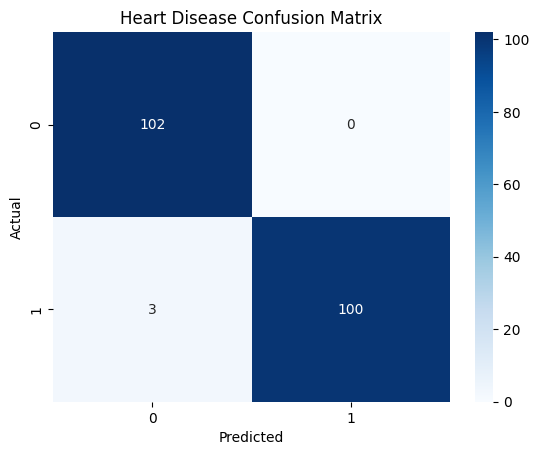

In [5]:
#Heart Disease

cm_heart = confusion_matrix(yh_test, yh_pred)

sns.heatmap(cm_heart, annot=True, fmt="d", cmap="Blues")
plt.title("Heart Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

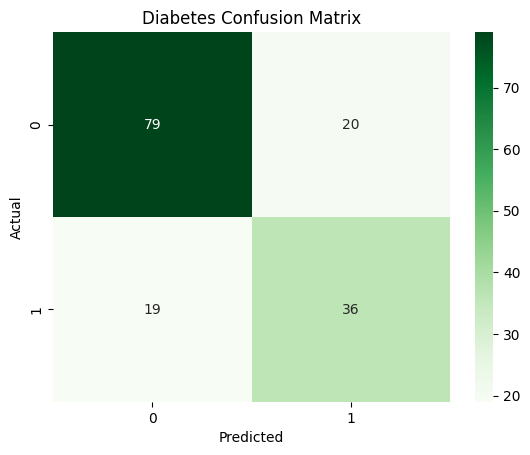

In [6]:
#Diabetes 

cm_diabetes = confusion_matrix(yd_test, yd_pred)
sns.heatmap(cm_diabetes, annot=True, fmt="d", cmap="Greens")
plt.title("Diabetes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

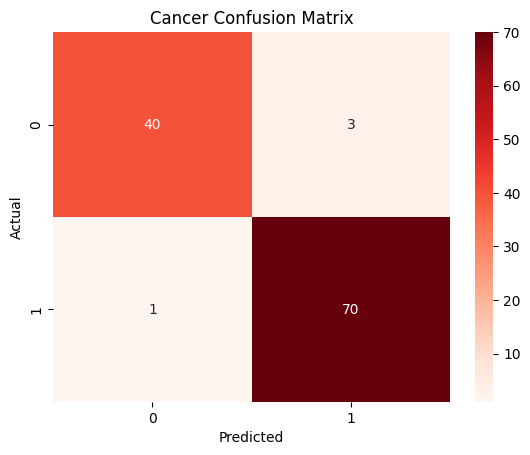

In [7]:
#Cancer

cm_cancer = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm_cancer, annot=True, fmt="d", cmap="Reds")
plt.title("Cancer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [8]:
#Heart Disease

print("HEART REPORT")
print(classification_report(yh_test, yh_pred))

HEART REPORT
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [9]:
#Diabetes

print("DIABETES REPORT")
print(classification_report(yd_test, yd_pred))

DIABETES REPORT
              precision    recall  f1-score   support

           0       0.81      0.80      0.80        99
           1       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [10]:
#Cancer

print("CANCER REPORT")
print(classification_report(yc_test, yc_pred))

CANCER REPORT
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Precision, Recall and F1 Score

In [11]:
def evaluate_metrics(y_true, y_pred, name):
    print(f"\n{name}")
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

In [12]:
#Run for each disease
evaluate_metrics(yh_test, yh_pred, "Heart Disease")
evaluate_metrics(yd_test, yd_pred, "Diabetes")
evaluate_metrics(yc_test, yc_pred, "Cancer")


Heart Disease
Precision: 1.0
Recall: 0.970873786407767
F1 Score: 0.9852216748768473

Diabetes
Precision: 0.6428571428571429
Recall: 0.6545454545454545
F1 Score: 0.6486486486486487

Cancer
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1 Score: 0.9722222222222222


ROC Curve


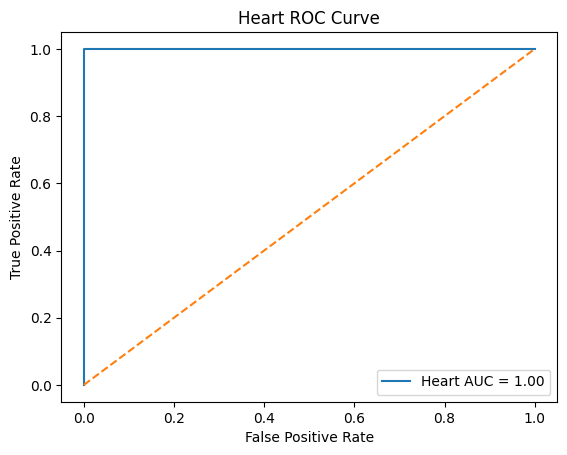

In [13]:
#Heart

yh_prob = heart_model.predict_proba(Xh_test)[:,1]

fpr, tpr, _ = roc_curve(yh_test, yh_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Heart AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Heart ROC Curve")
plt.legend()
plt.show()

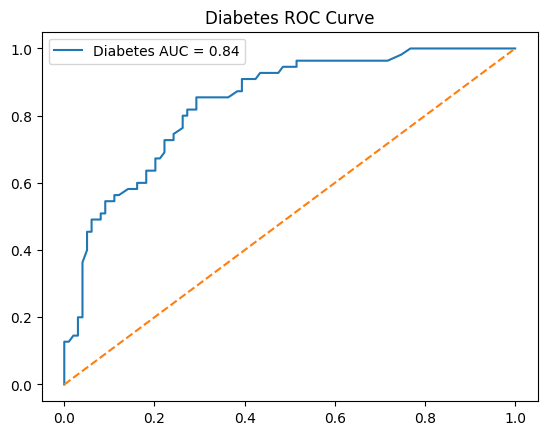

In [14]:
#Diabetes

yd_prob = diabetes_model.predict_proba(Xd_test)[:,1]

fpr, tpr, _ = roc_curve(yd_test, yd_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Diabetes AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("Diabetes ROC Curve")
plt.show()

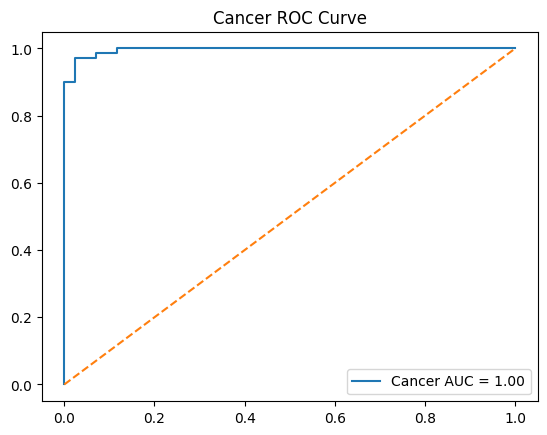

In [15]:
#Cancer
yc_prob = cancer_model.predict_proba(Xc_test)[:,1]

fpr, tpr, _ = roc_curve(yc_test, yc_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"Cancer AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("Cancer ROC Curve")
plt.show()

Final Insight Table

In [16]:
results = pd.DataFrame({
    "Model": ["Heart", "Diabetes", "Cancer"],
    "Goal": [
        "Max Recall (avoid missed heart disease)",
        "Balanced",
        "High Recall (critical)"
    ]
})

results

,Model,Goal
0,Heart,Max Recall (avoid missed heart disease)
1,Diabetes,Balanced
2,Cancer,High Recall (critical)
